In [6]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
train = pd.read_csv("train_used_car.csv")
test = pd.read_csv("test_user_car.csv")
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB
None


In [3]:
X = train.drop(columns=["price"])
y = train["price"]


In [4]:
cat_cols = X.select_dtypes(include="object").columns.tolist()

# Initialize encoder that handles unseen categories
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Fit on training data, transform both
X[cat_cols] = encoder.fit_transform(X[cat_cols])
test[cat_cols] = encoder.transform(test[cat_cols])


In [5]:
X.fillna(-1, inplace=True)
test.fillna(-1, inplace=True)


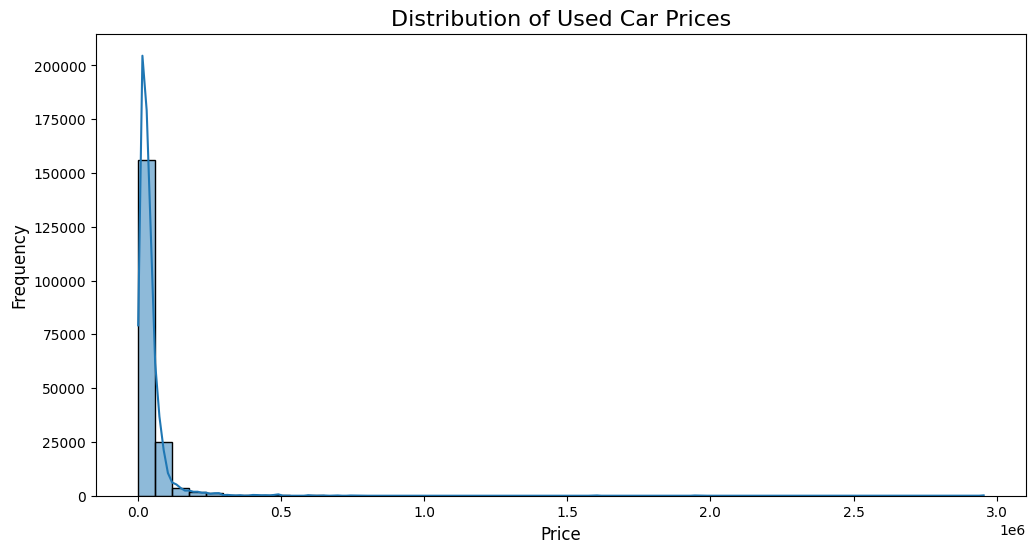

C:\Users\mrith\AppData\Local\Temp\ipykernel_28308\1818864239.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='brand', data=train, order=top_brands, palette='viridis')


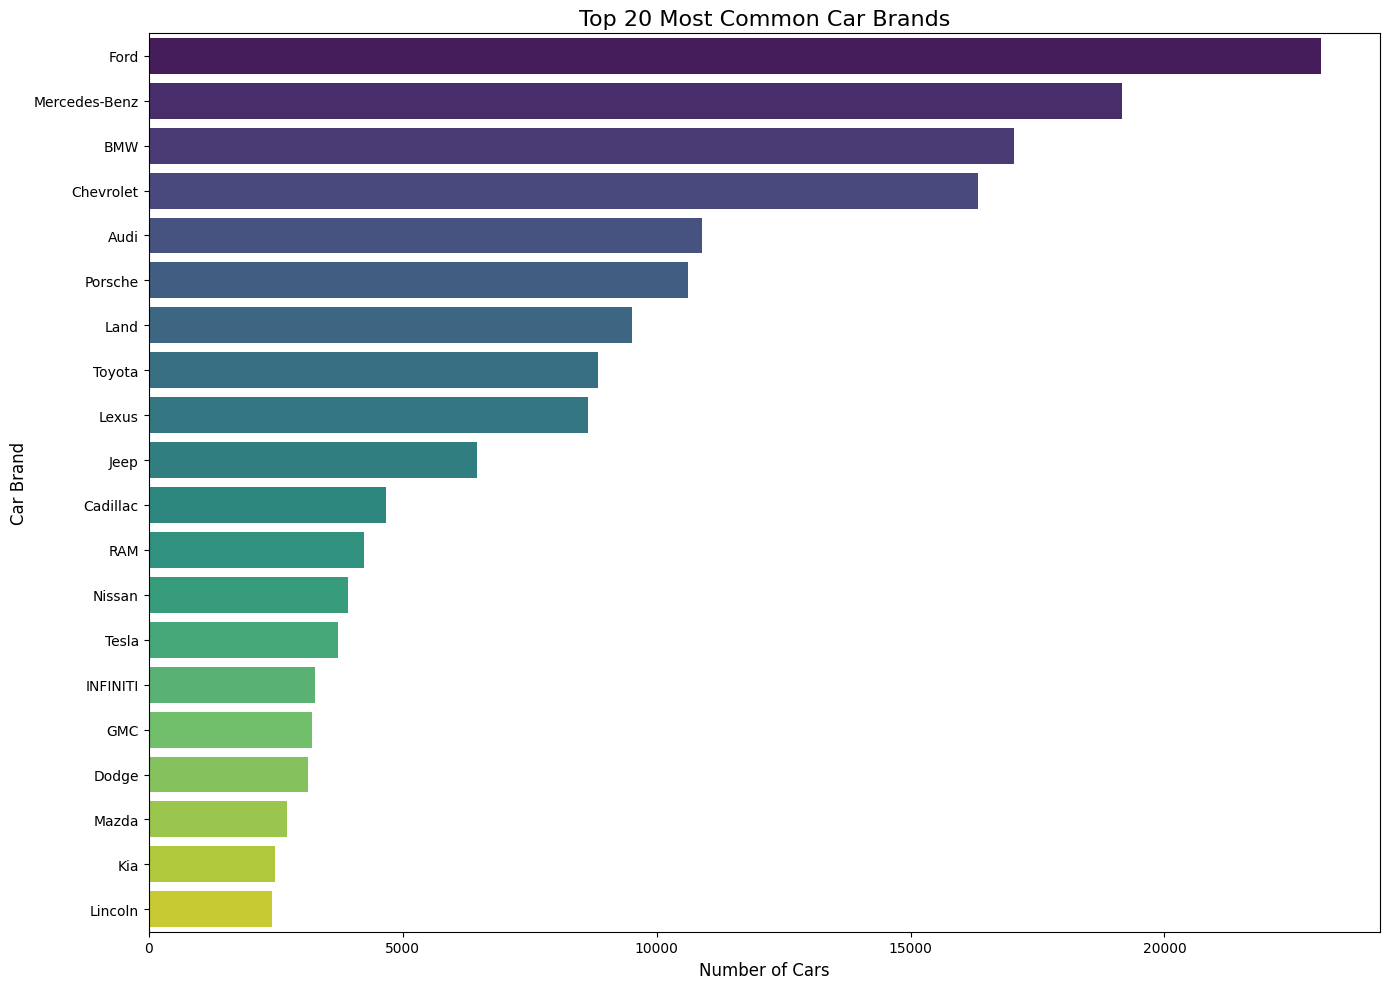

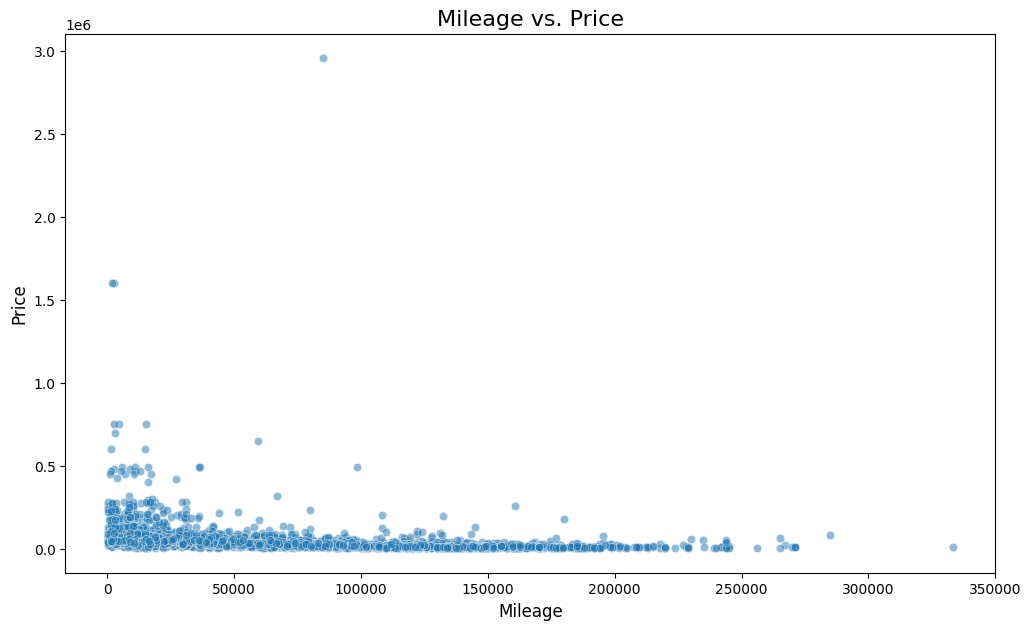

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(train['price'], kde=True, bins=50)
plt.title('Distribution of Used Car Prices', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


# --- 2. Car Brands Frequency Bar Chart ---
# This bar chart shows the number of listings for each car brand.
# It helps identify the most popular or common brands in the dataset.
plt.figure(figsize=(14, 10))
# Get the top 20 brands for cleaner visualization
top_brands = train['brand'].value_counts().nlargest(20).index
sns.countplot(y='brand', data=train, order=top_brands, palette='viridis')
plt.title('Top 20 Most Common Car Brands', fontsize=16)
plt.xlabel('Number of Cars', fontsize=12)
plt.ylabel('Car Brand', fontsize=12)
plt.tight_layout()
plt.show()


# --- 3. Mileage vs. Price Scatter Plot ---
# This scatter plot visualizes the relationship between a car's mileage and its price.
# We expect to see a negative correlation, where higher mileage corresponds to a lower price.
plt.figure(figsize=(12, 7))
# Using a sample to avoid overplotting and make the trend clearer
sample_data = train.sample(n=5000, random_state=42)
sns.scatterplot(x='milage', y='price', data=sample_data, alpha=0.5)
plt.title('Mileage vs. Price', fontsize=16)
plt.xlabel('Mileage', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.show()


In [ ]:
model = RandomForestRegressor(random_state=42, n_estimators=200)
model.fit(X, y)

In [56]:
preds = model.predict(test)

# Create submission file
submission = pd.DataFrame({
    "id": test["id"],
    "price": preds
})

submission.to_csv("submission_car.csv", index=False)
print("✅ submission.csv created successfully!")


✅ submission.csv created successfully!
